In [27]:
#Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from scipy.optimize import curve_fit
import pandas as pd
import scipy.stats as stats 
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import tkinter as tk
from tkinter import filedialog
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

In [28]:
#Input directory and file saving function 
root = tk.Tk()
root.withdraw()
print("If pop up box not seen minimise spyder and select folder wanted for analysis")
#folder_path = filedialog.askdirectory(title='Select input folder')
#save_path = filedialog.askdirectory(title='Select Folder to Save Plot')

    
def save_plot_with_folder_dialog(fig, default_filename='plot.jpeg'):
    root = tk.Tk()
    root.withdraw()  # Hide the root window

    folder_path = filedialog.askdirectory(title='Select Folder to Save Plot')
    if not folder_path:
        print("Save cancelled.")
        return

    full_path = os.path.join(folder_path, default_filename)
    fig.savefig(full_path)
    print(f"Plot saved to: {full_path}")
    
def save_plot_to_folder(fig, folder_path, filename='plot.jpeg'):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)  # Create the folder if it doesn't exist
    
    full_path = os.path.join(folder_path, filename)
    fig.tight_layout()
    fig.savefig(full_path, dpi=1000, bbox_inches='tight')
    print(f"Plot saved to: {full_path}")


If pop up box not seen minimise spyder and select folder wanted for analysis


In [29]:
#Colourmap formatting
# Change c1 and c2 based on the min and max colours to be chosen 

def hex_to_RGB(hex_str):
    
    """ #FFFFFF -> [255,255,255]"""
    
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):

    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


colors=[]
c1='#1A85FF'#deep blue
c2='#D41159' # deep pink
c3= '#744db0' # purple

GB_U_color = "5CBBFF"
GI_U_color = "003357"
GB_P_color = "D69AAB"
GI_P_color = "8D1730"

In [30]:
#----Configuring folders needed----
# number of rows in txt files to skip
rows = 3
DATASET_MAP = {
    'Unpass_Dark_CPD': {'parent': 'unpassivated', 'type': 'Dark_CPD', 'colour1': "#5CBBFF", 'colour2': "#003357"},
    'Unpass_On_CPD': {'parent': 'unpassivated', 'type': 'Illuminated_CPD', 'colour1': "#5CBBFF", 'colour2': "#003357"},
    'Unpass_Off_CPD': {'parent': 'unpassivated', 'type': 'Recovery_CPD', 'colour1': "#5CBBFF", 'colour2': "#003357"},
    'Unpass_On_SPV': {'parent': 'unpassivated', 'type': 'Illuminated_SPV', 'colour1': "#5CBBFF", 'colour2': "#003357"},
    'Unpass_Off_SPV': {'parent': 'unpassivated', 'type': 'Recovery_SPV', 'colour1': "#5CBBFF", 'colour2': "#003357"},
    'Pass_Dark_CPD': {'parent': 'passivated', 'type': 'Dark_CPD', 'colour1': "#D69AAB", 'colour2': "#8D1730"},
    'Pass_On_CPD': {'parent': 'passivated', 'type': 'Illuminated_CPD', 'colour1': "#D69AAB", 'colour2': "#8D1730"},
    'Pass_Off_CPD': {'parent': 'passivated', 'type': 'Recovery_CPD', 'colour1': "#D69AAB", 'colour2': "#8D1730"},
    'Pass_On_SPV': {'parent': 'passivated', 'type': 'Illuminated_SPV', 'colour1': "#D69AAB", 'colour2': "#8D1730"},
    'Pass_Off_SPV': {'parent': 'passivated', 'type': 'Recovery_SPV', 'colour1': "#D69AAB", 'colour2': "#8D1730"},
}


In [31]:
# --- Directory Selection Functions ---

def select_root_path():
    """Opens a single dialog to select the top-level ROOT_PATH."""
    root_path = filedialog.askdirectory(title='Select the Top-Level ROOT_PATH Folder')
    if not root_path:
        print("No root path selected. Exiting.")
        return None
    return root_path

In [32]:
# Gaussian fitting (Multigaussian) 
# Function to model N Gaussians
def multi_gaussian(x, *params):
    n = len(params) // 3
    y = np.zeros_like(x)
    for i in range(n):
        amp = params[i * 3]
        cen = params[i * 3 + 1]
        wid = params[i * 3 + 2]
        y += amp * np.exp(-((x - cen) ** 2) / (2 * wid ** 2))
    return y

# Auto-generate initial guess based on data
def estimate_guess_from_data(x, y, prominence=0.1, distance=10):
    y_smooth = gaussian_filter1d(y, sigma=2)
    peaks, _ = find_peaks(y_smooth, prominence=prominence, distance=distance)
    
    # Sort peaks by height (amplitude) and limit to top 2
    if len(peaks) > 2:
        sorted_indices = np.argsort(properties['prominences'])[::-1][:2]
        peaks = peaks[sorted_indices]

    guess = []
    for i in peaks:
        amp = y[i]
        cen = x[i]
        wid = 0.001 # Adjust based on data
        guess += [amp, cen, wid]
    
    return guess, len(peaks)


In [33]:
#Single gaussian def: 
#Fitting equation
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

In [ ]:
# --- Gaussian fitting---
def fit_gaussian (file_path, rows):
    """Performs Gaussian fitting on data from a given file path."""
    with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
        data = np.loadtxt(f, skiprows=rows)
        
    x_data = data[:, 0]
    y_data = data[:, 1]
    
    # Estimate initial guess and peak count (Assumes estimate_guess_from_data is defined) Multigaussian
    #initial_guess, n_peaks = estimate_guess_from_data(x_data, y_data)
    #popt, _ = curve_fit(multi_gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
    #Estimate initial guess Single gaussian
    initial_guess = [max(y_data), np.mean(x_data), np.std(x_data)]
    popt, pcov = curve_fit(gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)

    
    x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
    #y_fit=multi_gaussian(x_fit,*popt)
    y_fit=gaussian(x_fit,*popt)
    peak_index_max=np.argmax(y_fit)
    peak_centre=x_fit[peak_index_max]
    
    # Extract Gaussian parameters
    gaussians = []
    for i in range(len(popt) // 3):
        amp = popt[i*3]
        cen = popt[i*3+1]
        wid = abs(popt[i*3+2])
        gaussians.append({'amp': amp, 'cen': cen, 'wid': wid})

    highest = gaussians[np.argmax([g['amp'] for g in gaussians])]
    fwhm = 2.355 * highest['wid']
    
    return x_data, y_data, x_fit, y_fit, peak_centre, fwhm

In [ ]:
#Specific grain boundary function
def grain_boundaries(GB_file_path, GI_file_path, pixel_index, save_path, GB_colour='input', GI_colour='input', datatype='CPD/SPV'):
    """
    Fits Gaussian to GB and GI data, plots the results, saves the plot, 
    and writes the analysis data to a text file.
    """
    # Pixel number corresponds to the 'pixels' value (1 to 5)
    pixels = pixel_index 
    
    # Perform fitting
    GB_x_raw_1, GB_y_raw_1, GB_x_1, GB_y_1, GB_peak_1, GB_fwhm_1 = fit_gaussian(GB_file_path, rows)
    GI_x_raw_1, GI_y_raw_1, GI_x_1, GI_y_1, GI_peak_1, GI_fwhm_1 = fit_gaussian(GI_file_path, rows)
    peak_diff_1 = (GB_peak_1 - GI_peak_1)*1000

    #Adjusting arrays to give results in mV
    GB_x_raw = [round(x*1000, 4) if not np.isnan(x) else np.nan for x in GB_x_raw_1]
    GI_x_raw = [round(x*1000, 4) if not np.isnan(x) else np.nan for x in GI_x_raw_1]
    GB_x_fit=[round(x*1000, 4) if not np.isnan(x) else np.nan for x in GB_x_1]
    GI_x_fit=[round(x*1000, 4) if not np.isnan(x) else np.nan for x in GI_x_1]
    # Plotting functions: 
    fig, ax = plt.subplots(1, 1, sharey=True, figsize=(10,8))
    plt.rcParams.update({'font.size': 36}) # Use a slightly smaller font for general text
    
    ax.tick_params(direction='in', length=6)
    ax.tick_params(axis='both')#, labelsize=18)
    #ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.margins(0.05, 0.05) # Reduced margins for a tighter plot
    ax.set_xlabel(f"{datatype} (mV)")#, fontsize=22)
    
    # Calculate limits from all fitted data for consistent scaling
    x_data_all = np.concatenate([GB_x_raw, GB_x_fit, GI_x_raw, GI_x_fit])
    y_data_all = np.concatenate([GB_y_raw_1, GB_y_1, GI_y_raw_1, GI_y_1])
    ax.set_xlim(np.min(x_data_all) - 10, np.max(x_data_all) + 10)
    ax.set_ylabel("Distribution (V$^{-1}$)")#, fontsize=22)
    ax.set_ylim(0, np.max(y_data_all)+5)
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5)) 
    
    # Plotting
    plt.scatter(GB_x_raw, GB_y_raw_1, label=f"GB Data", color=GB_colour, s=30)
    plt.plot(GB_x_fit, GB_y_1, label=f"_nolegend_", color=GB_colour, linewidth=3)
    plt.scatter(GI_x_raw, GI_y_raw_1, label=f"GI Data", color=GI_colour, s=30, marker='s')
    plt.plot(GI_x_fit, GI_y_1, label=f"_nolegend_", color=GI_colour, linewidth=3, linestyle='--')
    
    plt.legend(loc='upper right', fontsize=24)
    
    # Save Plot
    # Assumes save_plot_to_folder is defined and handles the saving
    fig=plt.gcf()
    plot_filename = f'GrainBoundary_Interior_MultiGaussian_{pixels*20}_nm.jpeg'
    save_plot_to_folder(fig, save_path, filename=plot_filename)
    plt.close(fig) # Close figure to prevent memory issues

    # Save Analysis Output
    output_file = os.path.join(save_path, f'GrainBoundaries_analysis_output_{pixels*20}_nm.txt')
    with open(output_file, 'w') as f:
        output_lines = [
            f"Analysis for {pixels*20} nm [in mV]:",
            "Grain boundary peak = " + str(GB_peak_1*1000),
            "Grain boundary fwhm = " + str(GB_fwhm_1*1000),
            "Grain boundary min, max spread = " + str(GB_min_1*1000) + ", " + str(GB_max_1*1000),
            "Grain interior peak = " + str(GI_peak_1*1000),
            "Grain interior fwhm = " + str(GI_fwhm_1*1000),
            "Grain interior min, max spread = " + str(GI_min_1*1000) + ", " + str(GI_max_1*1000),
            "Diff of GB/GI =" + str(peak_diff_1),
        ]
        for line in output_lines:
            f.write(line + '\n')
            
    return peak_diff_1

In [48]:
def GB_diff_processing_final(root_path, dataset_key):
    """
    Processes all 5 pixel files for a given dataset using the fixed file structure:
    ROOT_PATH/parent/type/GB/1.txt
    """
    if not root_path:
        return [np.nan] * 5

    config = DATASET_MAP[dataset_key]
    parent_folder = config['parent']
    type_folder = config['type']
    colour1 = config['colour1']
    colour2 = config['colour2']

    print(f"\n--- Processing: {dataset_key} ---")

    # 1. Define the base folder containing GB/GI subfolders
    # This path is: ROOT_PATH/unpassivated/Dark_CPD
    base_data_folder = os.path.join(root_path, parent_folder, type_folder)
    
    # 2. Define the exact GB and GI folders
    GB_folder = os.path.join(base_data_folder, 'GB')
    GI_folder = os.path.join(base_data_folder, 'GI')
    
    # 3. Define the save path for intermediate plots and text files
    # This will be: ROOT_PATH/Plots/unpassivated/Dark_CPD
    save_path = os.path.join(root_path, 'Plots', parent_folder, type_folder)
    os.makedirs(save_path, exist_ok=True) # Create folder if it doesn't exist

    y_peaks = []
    
    # Check if the necessary folders exist before starting the loop
    if not os.path.isdir(GB_folder) or not os.path.isdir(GI_folder):
        print(f"Error: Could not find 'GB' and/or 'GI' folders at {base_data_folder}. Skipping.")
        return [np.nan] * 5

    # 4. Iterate through the 5 pixel files (1 to 5)
    for pixel_index in range(1, 6):
        
        # Construct the file paths: e.g., .../GB/1.txt and .../GI/1.txt
        file_name = f'{pixel_index}.txt'
        GB_file_path = os.path.join(GB_folder, file_name)
        GI_file_path = os.path.join(GI_folder, file_name)
        #print(GB_file_path)
        #print(GI_file_path)
        if os.path.exists(GB_file_path) and os.path.exists(GI_file_path):
            print(f"  Processing Pixel {pixel_index}...")
            if 'CPD' in type_folder:
                measurement_type = 'CPD'
                print(f"Folder is a CPD measurement: {type_folder}")
            elif 'SPV' in type_folder:
                measurement_type = 'SPV'
                print(f"Folder is an SPV measurement: {type_folder}")
            else:
                measurement_type = 'Unknown'
                print(f"Folder type is neither CPD nor SPV: {type_folder}")
            peak_diff = grain_boundaries(
                GB_file_path, 
                GI_file_path, 
                pixel_index, 
                save_path, 
                colour1, 
                colour2,
                datatype = f"{measurement_type}"
            )
            y_peaks.append(peak_diff)
        else:
            print(f"  File(s) not found for Pixel {pixel_index}. Skipping.")
            print(f"{GB_file_path}")
            y_peaks.append(np.nan) 

    # Convert peak differences to mV and round
    y_peaks_adjusted = [round(x, 4) if not np.isnan(x) else np.nan for x in y_peaks]
    return y_peaks_adjusted


--- Starting Batch Processing ---

--- Processing: Unpass_Dark_CPD ---
  Processing Pixel 1...
Folder is a CPD measurement: Dark_CPD
Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/SPV_OrganisedFolders\Plots\unpassivated\Dark_CPD\GrainBoundary_Interior_MultiGaussian_20_nm.jpeg
  Processing Pixel 2...
Folder is a CPD measurement: Dark_CPD
Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/SPV_OrganisedFolders\Plots\unpassivated\Dark_CPD\GrainBoundary_Interior_MultiGaussian_40_nm.jpeg
  Processing Pixel 3...
Folder is a CPD measurement: Dark_CPD
Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/SPV_OrganisedFolders\Plots\unpassivated\Dark_CPD\GrainBoundary_Interior_MultiGaussian_60_nm.jpeg
  Processing Pixel 4...
Folder is a CPD measurement:

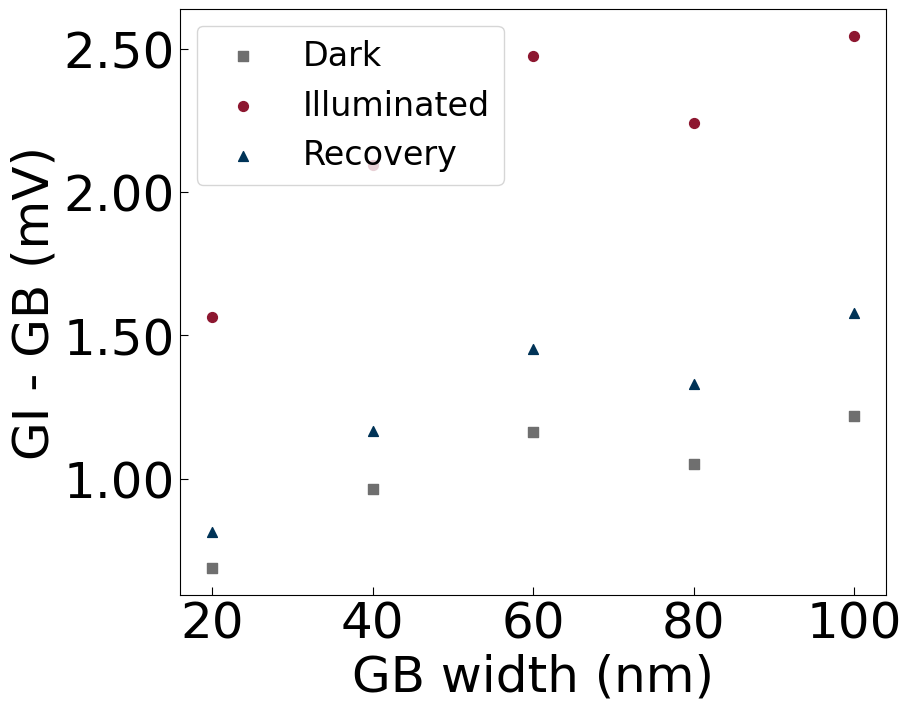

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/SPV_OrganisedFolders/Final_Plots_Summary\FullScatternm_SPV_Unpassivated.jpeg


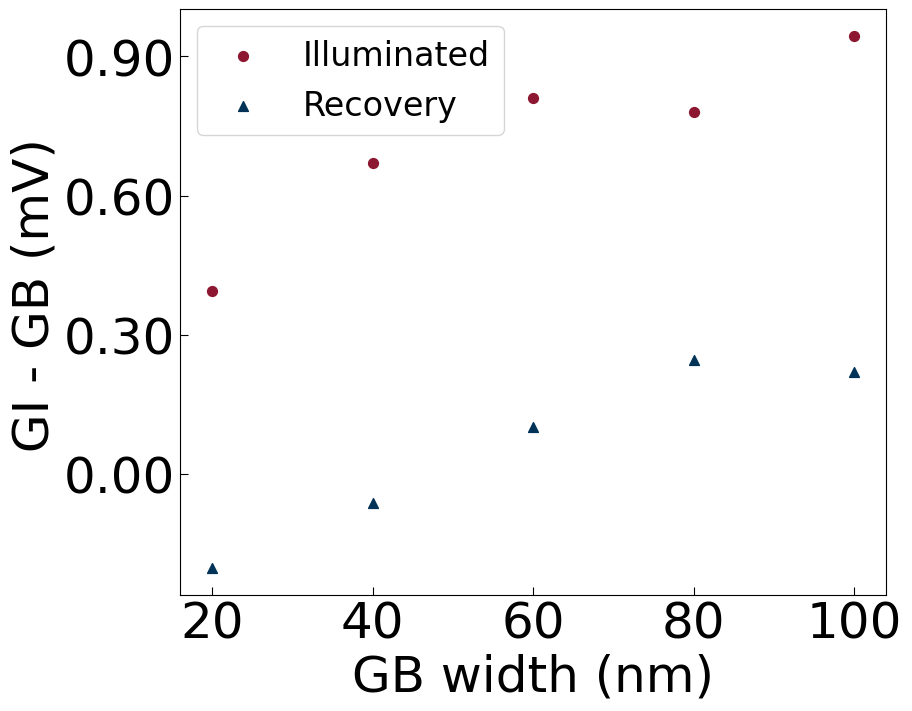

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/SPV_OrganisedFolders/Final_Plots_Summary\FullScatternm_CPD_Passivated.jpeg


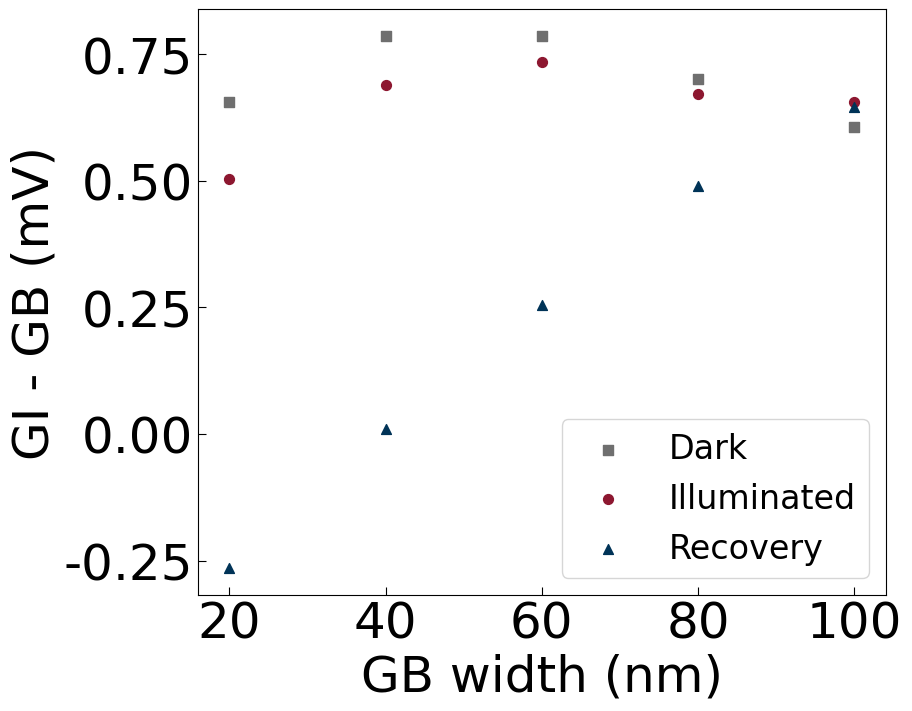

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/SPV_OrganisedFolders/Final_Plots_Summary\FullScatternm_SPV_Passivated.jpeg


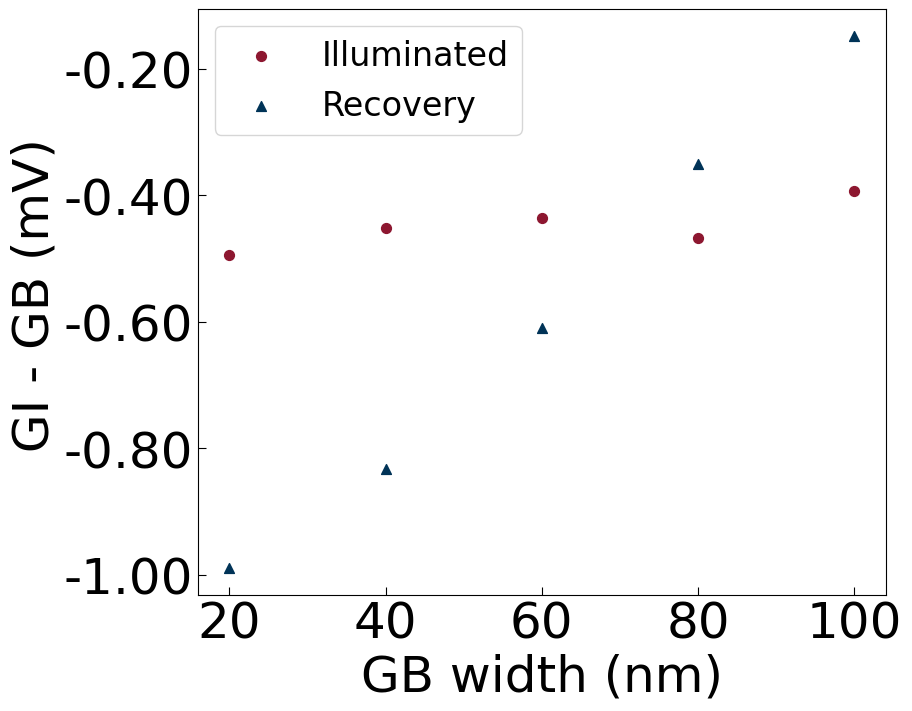

In [50]:
# --- Main Execution Block ---

ROOT_PATH = select_root_path()

if ROOT_PATH:
    # Get a list of all dataset keys
    all_datasets = list(DATASET_MAP.keys())
    
    # Initialize dictionary to store results
    all_results = {}
    
    print("\n--- Starting Batch Processing ---")
    
    # Loop through all datasets, calling the processing function
    for dataset_key in all_datasets:
        all_results[dataset_key] = GB_diff_processing_final(ROOT_PATH, dataset_key)

    # Assign results to original variables for summary plotting
    Unpass_Dark_CPD = all_results['Unpass_Dark_CPD']
    Unpass_On_CPD = all_results['Unpass_On_CPD']
    Unpass_Off_CPD = all_results['Unpass_Off_CPD']
    Unpass_On_SPV = all_results['Unpass_On_SPV']
    Unpass_Off_SPV = all_results['Unpass_Off_SPV']
    Pass_Dark_CPD = all_results['Pass_Dark_CPD']
    Pass_On_CPD = all_results['Pass_On_CPD']
    Pass_Off_CPD = all_results['Pass_Off_CPD']
    Pass_On_SPV = all_results['Pass_On_SPV']
    Pass_Off_SPV = all_results['Pass_Off_SPV']

    # --- Summary Plotting ---
    print("\n--- Summary Plotting ---")
    FINAL_PLOTS_SAVE_PATH = filedialog.askdirectory(title='Select Folder to Save All Final Summary Plots')

    # --- Summary Plotting ---
    x_nm = [20, 40, 60, 80, 100]
    
    # 1. Unpassivated CPD Plot
    plt.rcParams.update({'font.size': 36})
    plt.figure(figsize=(10,8))
    ax = plt.gca()
    # ... (Plot formatting identical to original code, but reduced font size for cleaner fit)
    ax.tick_params(direction='in', length=6)
    ax.tick_params(axis='both')#, labelsize=18)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    plt.xlabel("GB width (nm)")#, fontsize=20)
    plt.ylabel("GI - GB (mV)")#, fontsize=20)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    
    plt.scatter(x_nm, Unpass_Dark_CPD, label='Dark', color='#6F6F6F', marker='s', s=50)
    plt.scatter(x_nm, Unpass_On_CPD, label='Illuminated', color='#8D1730', marker='o', s=50)
    plt.scatter(x_nm, Unpass_Off_CPD, label='Recovery', color='#003357', marker='^', s=50)
    plt.legend(loc='upper left', fontsize=24)
    plt.tight_layout()
    save_plot_to_folder(plt.gcf(), FINAL_PLOTS_SAVE_PATH, filename='FullScatternm_CPD_Unpassivated.jpeg')
    plt.show()

    # 2. Unpassivated SPV Plot
    plt.figure(figsize=(10,8))
    ax = plt.gca()
    # ... (Plot formatting)
    ax.tick_params(direction='in', length=6)
    ax.tick_params(axis='both')#, labelsize=18)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    plt.xlabel("GB width (nm)")#, fontsize=20)
    plt.ylabel(" GI - GB (mV)")#, fontsize=20)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    
    plt.scatter(x_nm, Unpass_On_SPV, label='Illuminated', color='#8D1730', marker='o', s=50)
    plt.scatter(x_nm, Unpass_Off_SPV, label='Recovery', color='#003357', marker='^', s=50)
    plt.legend(fontsize=24)
    plt.tight_layout()
    save_plot_to_folder(plt.gcf(), FINAL_PLOTS_SAVE_PATH, filename='FullScatternm_SPV_Unpassivated.jpeg')
    plt.show()

    # 3. Passivated CPD Plot
    plt.figure(figsize=(10,8))
    ax = plt.gca()
    # ... (Plot formatting)
    ax.tick_params(direction='in', length=6)
    ax.tick_params(axis='both')#, labelsize=18)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    plt.xlabel("GB width (nm)")#, fontsize=20)
    plt.ylabel("GI - GB (mV)")#, fontsize=20)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    
    plt.scatter(x_nm, Pass_Dark_CPD, label='Dark', color='#6F6F6F', marker='s', s=50)
    plt.scatter(x_nm, Pass_On_CPD, label='Illuminated', color='#8D1730', marker='o', s=50)
    plt.scatter(x_nm, Pass_Off_CPD, label='Recovery', color='#003357', marker='^', s=50)
    plt.legend(loc='lower right', fontsize=24)
    plt.tight_layout()
    save_plot_to_folder(plt.gcf(), FINAL_PLOTS_SAVE_PATH, filename='FullScatternm_CPD_Passivated.jpeg')
    plt.show()

    # 4. Passivated SPV Plot
    plt.figure(figsize=(10,8))
    ax = plt.gca()
    # ... (Plot formatting)
    ax.tick_params(direction='in', length=6)
    ax.tick_params(axis='both')#, labelsize=18)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    plt.xlabel("GB width (nm)")#, fontsize=20)
    plt.ylabel(" GI - GB (mV)")#, fontsize=20)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    
    plt.scatter(x_nm, Pass_On_SPV, label='Illuminated', color='#8D1730', marker='o', s=50)
    plt.scatter(x_nm, Pass_Off_SPV, label='Recovery', color='#003357', marker='^', s=50)
    plt.legend(fontsize=24)
    plt.tight_layout()
    save_plot_to_folder(plt.gcf(), FINAL_PLOTS_SAVE_PATH, filename='FullScatternm_SPV_Passivated.jpeg')
    plt.show()
